In [1]:
# Example plots of pressure data Hybrid Dune Campaign

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
nc_QC  = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\QC\Deployment period 1\Pressure sensor S3 P_BS3 (RBR) QC p_rel - period 1.nc'
nc_processed = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 1\Pressure sensor S3 P_BS3 (RBR) processed data - period 1.nc'

#nc_QC  = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\QC\Deployment period 2\Pressure sensor S3P3 RBR6 p_rel - period 2.nc'
#nc_processed = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 2\Pressure sensor S3P3 RBR6 processed data - period 2.nc'


ds_QC = xr.open_dataset(nc_QC)
ds_processed = xr.open_dataset(nc_processed)

ds_processed # print the variables in ds_processed

<xarray.Dataset> Size: 543MB
Dimensions:      (t_zb: 3, t_full: 8409600, t_block: 438, f: 480)
Coordinates:
  * t_zb         (t_zb) datetime64[ns] 24B 2024-12-17T10:30:00 ... 2024-12-23...
  * t_full       (t_full) datetime64[ns] 67MB 2024-12-17T11:00:00 ... 2024-12...
  * t_block      (t_block) datetime64[ns] 4kB 2024-12-17T11:00:00 ... 2024-12...
  * f            (f) float64 4kB 0.0 0.01667 0.03333 0.05 ... 7.95 7.967 7.983
Data variables: (12/40)
    zb           (t_zb) float64 24B ...
    t_zi         datetime64[ns] 8B ...
    zi           float64 8B ...
    x_RD         float64 8B ...
    y_RD         float64 8B ...
    x_local      float64 8B ...
    ...           ...
    Hm0_WW       (t_block) float64 4kB ...
    Tp_WW        (t_block) float64 4kB ...
    Tm01_WW      (t_block) float64 4kB ...
    Tm02_WW      (t_block) float64 4kB ...
    Tmm10_WW     (t_block) float64 4kB ...
    Tps_WW       (t_block) float64 4kB ...
Attributes: (12/17)
    Conventions:               CF-1.6
    name:                      Pressure sensor S3P3 RBR, period 1
    instrument:                Pressure sensor S3P3 RBR6
    instrument type:           Ruskin RBR Solo
    instrument serial number:  208682
    epsg:                      28992
    ...                        ...
    emailadres:                d.w.poppema@tudelft.nl
    construction datetime:     09-Sep-2025 17:13:57
    version:                   v1
    comment_1:                 subscripts IG and WW in variable names refer t...
    url of online dataset:     ADD LATER
    comment_2:                 constructed with xarray

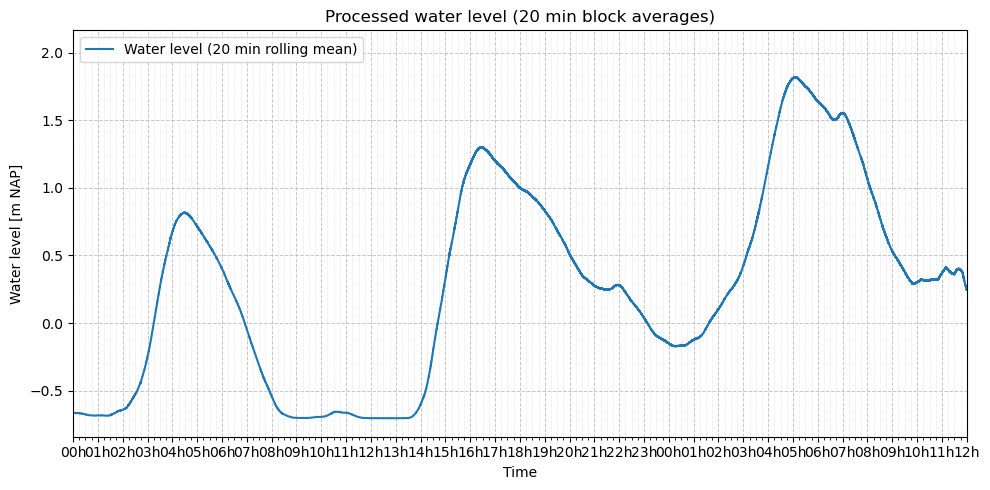

In [4]:
# --- Plot processed water level time series (homogenised style) ---
fig, ax = plt.subplots(figsize=(10, 5))

# Plot full-resolution and block-averaged water level
# ax.plot(ds_processed.t_full, ds_processed.zs, label='Water level', color='tab:blue') # full times series
# ax.plot(ds_processed.t_block, ds_processed.zs_mean,  label='Mean water level (block avg)', color='orange') # block averages, shifted to start of block

zs_rolling = ds_processed.zs.rolling(t_full=ds_QC.sf.values * 60 * 20, center=True).mean()
ax.plot(ds_processed.t_full, zs_rolling, label='Water level (20 min rolling mean)', color='tab:blue') # block averages, at block center

# Mark storm event 1
#ax.axvline(pd.Timestamp('2024-12-19 18:00'), color='red', linestyle='--', label='Peak storm 1')

# Axes and labels
ax.set_xlabel('Time')
ax.set_ylabel('Water level [m NAP]')

# Grid, title, legend
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))             # Set minor ticks every hour
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Hh'))

ax.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)  # Add minor grid


ax.set_title('Processed water level (20 min block averages)')
ax.legend(loc='upper left')
ax.set_xlim(pd.Timestamp('2024-12-18 00:00'), pd.Timestamp('2024-12-19 12:00'))
#ax.set_xlim(pd.Timestamp('2024-12-22 04:00'), pd.Timestamp('2024-12-22 22:00'))

#ax.set_xlim(pd.Timestamp('2024-12-31 15:00'), pd.Timestamp('2025-01-02 03:00'))

fig.tight_layout()
plt.show()
